In [1]:
import enum
import os
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.dataset as pads
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from skarf import set_cache_dir
from skarf.covariance import load_spi_config_map

In [2]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [3]:
fc_colors = np.array(
    [
        [64, 80, 160],
        [64, 96, 176],
        [96, 192, 240],
        [144, 208, 224],
        [255, 255, 255],
        [240, 240, 96],
        [240, 208, 64],
        [224, 112, 64],
        [224, 64, 48],
    ],
    dtype=np.uint8,
)

FC_CMAP = LinearSegmentedColormap.from_list("fc", fc_colors / 255.0)

In [4]:
project_root = Path(os.environ["PROJECT_ROOT"])

analyze_test_profile_dir = project_root / "results/analyze_test_profile_pyspi"
analyze_test_profile_dir.mkdir(exist_ok=True)

In [5]:
spi_list_dir = project_root / "resources/spi_lists"
set_cache_dir(spi_list_dir)

spi_config_map, _ = load_spi_config_map()

In [6]:
all_spis = (spi_list_dir / "spi_list_all_284.txt").read_text().strip().split()
print("\n".join(all_spis[:10]))

cov_EmpiricalCovariance
cov_EllipticEnvelope
cov_GraphicalLasso
cov_GraphicalLassoCV
cov_LedoitWolf
cov_MinCovDet
cov_OAS
cov_ShrunkCovariance
cov-sq_EmpiricalCovariance
cov-sq_EllipticEnvelope


In [7]:
spi_id_map = {spi: idx for idx, spi in enumerate(all_spis)}

In [8]:
spi_table = pd.DataFrame.from_records(
    [
        {"spi_id": idx, "spi": spi, **spi_config_map[spi]}
        for idx, spi in enumerate(all_spis)
    ]
)

spi_table.insert(
    2, "category", [module.split(".")[-1] for module in spi_table["module_name"]]
)
spi_table.insert(3, "identifier", [spi.split("_")[0] for spi in spi_table["spi"]])
spi_table = spi_table.drop(columns=["module_name"])

spi_table.head(4)

,spi_id,spi,category,identifier,fcn,params
0,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'}
1,1,cov_EllipticEnvelope,basic,cov,Covariance,{'estimator': 'EllipticEnvelope'}
2,2,cov_GraphicalLasso,basic,cov,Covariance,{'estimator': 'GraphicalLasso'}
3,3,cov_GraphicalLassoCV,basic,cov,Covariance,{'estimator': 'GraphicalLassoCV'}


In [9]:
(
    spi_table.groupby("category")
    .agg({"fcn": "nunique", "spi": "count"})
    .sort_values("spi", ascending=False)
)

,fcn,spi
category,,
spectral,17,114
infotheory,10,43
basic,5,42
distance,12,42
misc,4,24
causal,5,13
wavelet,1,6


## Filtering SPIs

Here we load the test/profile results computed on one example run, varying the number of samples and features.

First we exclude SPIs that did not complete all three (valid) runs successfully. (Nb that some SPIs fail when `n_samples < n_features`.) This excludes SPIs that timed out or raised errors.

Then we exclude squared and precision (inverse covariance) SPIs, which are redundant.

We then filter by run time, applying a knee point cutoff to exclude outlier SPIs with long run time.

In [10]:
class IncludeCode(enum.StrEnum):
    INCLUDE = "I"
    DUPLICATE = "D"
    ERROR = "E"
    TIME = "T"


spi_include_codes = {spi: IncludeCode.INCLUDE for spi in all_spis}

In [11]:
test_profile_data_dir = project_root / "results/test_profile_pyspi"

df: pd.DataFrame = (
    pads.dataset(test_profile_data_dir, format="arrow").to_table().to_pandas()
)

# Join with spi table
df = spi_table.merge(df, how="right", on=["spi_id", "spi"])

print(df.shape)
print(df.dtypes)
df.iloc[:5, :9]

(1381, 13)
spi_id           int64
spi             object
category        object
identifier      object
fcn             object
params          object
n_samples        int32
n_features       int32
success           bool
run_time       float32
peak_mem_mb    float32
err             object
mat             object
dtype: object


,spi_id,spi,category,identifier,fcn,params,n_samples,n_features,success
0,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},50,100,True
1,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},100,100,True
2,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},200,100,True
3,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},400,100,True
4,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},400,200,True


In [12]:
# Check all SPIs have at least one record, i.e. no time outs on first trial (N=50, D=100)
print("All SPIs have at least one record:", df["spi"].nunique() == len(all_spis))

All SPIs have at least one record: True


In [13]:
spi_completion_counts = (
    df.query("n_samples >= 200")  # only look at trials with n_samples > n_features
    .groupby("spi")
    .agg({"spi": "count", "success": "sum"})
)

complete_spis = set(spi_completion_counts.query("success == 3").index)
complete_df = df.loc[df["spi"].isin(complete_spis)]
print(complete_df.shape)

(1265, 13)


In [14]:
incomplete_spis = [spi for spi in all_spis if spi not in complete_spis]
incomplete_df = df.loc[df["spi"].isin(incomplete_spis)]

In [15]:
incomplete_spi_completion_counts = (
    incomplete_df.groupby(["category", "spi"])
    .agg(
        {
            "spi": "count",
            "success": "sum",
            "n_samples": "max",
            "n_features": "max",
            "run_time": "max",
        }
    )
    .rename(columns={"spi": "count"})
    .sort_values(["count", "success"])
)

incomplete_spi_completion_counts

count  success  \
category   spi                                                                  
causal     ccm_E-10_diff                                           2        1   
           ccm_E-10_max                                            2        1   
           ccm_E-10_mean                                           2        1   
           ccm_E-None_diff                                         2        1   
           ccm_E-None_max                                          2        1   
           ccm_E-None_mean                                         2        1   
           ccm_E-1_diff                                            2        2   
           ccm_E-1_max                                             2        2   
           ccm_E-1_mean                                            2        2   
distance   mgcx_maxlag-10                                          3        3   
           bary-sq_softdtw_max                                     4        4   
           bary-sq_softdtw_mean                                    4        4   
           bary_softdtw_max                                        4        4   
           bary_softdtw_mean                                       4        4   
           hhg                                                     4        4   
           mgcx_maxlag-1                                           4        4   
infotheory te_kraskov_NN-4_DCE_k-max-10_tau-max-4                  4        4   
           te_kraskov_NN-4_k-max-10_tau-max-4                      4        4   
misc       gpfit_DotProduct                                        4        4   
           gpfit_RBF                                               4        4   
basic      cov-sq_GraphicalLasso                                   5        0   
           cov_GraphicalLasso                                      5        0   
           prec-sq_GraphicalLasso                                  5        0   
           prec_GraphicalLasso                                     5        0   
infotheory xme_gaussian_k10                                        5        0   
spectral   sgc_parametric_max_fs-1_fmin-0-25_fmax-0-5_orde...      5        0   
           sgc_parametric_max_fs-1_fmin-0_fmax-0-25_order-...      5        0   
           sgc_parametric_max_fs-1_fmin-1e-05_fmax-0-5_ord...      5        0   
           sgc_parametric_mean_fs-1_fmin-0-25_fmax-0-5_ord...      5        0   
           sgc_parametric_mean_fs-1_fmin-0_fmax-0-25_order...      5        0   
           sgc_parametric_mean_fs-1_fmin-0_fmax-0-5_order-...      5        0   

                                                               n_samples  \
category   spi                                                             
causal     ccm_E-10_diff                                             100   
           ccm_E-10_max                                              100   
           ccm_E-10_mean                                             100   
           ccm_E-None_diff                                           100   
           ccm_E-None_max                                            100   
           ccm_E-None_mean                                           100   
           ccm_E-1_diff                                              100   
           ccm_E-1_max                                               100   
           ccm_E-1_mean                                              100   
distance   mgcx_maxlag-10                                            200   
           bary-sq_softdtw_max                                       400   
           bary-sq_softdtw_mean                                      400   
           bary_softdtw_max                                          400   
           bary_softdtw_mean                                         400   
           hhg                                                       400   
           mgcx_maxlag-1                                             400   
infotheory te_kraskov

- First 20 SPIs timed out with 1 hour per trial time limit. This is far too long to spend computing one connectivity matrix...

- `GraphicalLasso` fails bc of bad default regularization strength. `GraphicalLassoCV` works fine though.

- `sgc` with order `None` fails with this error

  ```
  ValueError: Model estimation order did not converge at max_order = 50
  ```

  But variants of sgc with order not equal to None work fine.

- `xme_gaussian_k10` fails with following error (rank deficient)

  ```
  infodynamics.utils.NonPositiveDefiniteMatrixException: infodynamics.utils.NonPositiveDefiniteMatrixException: CholeskyDecomposition is only performed on positive-definite matrices. Some reasons for non-positive-definite matrix are listed at http://www2.gsu.edu/~mkteer/npdmatri.html - note: a correlation matrix is non-positive-definite if you have more variables than observations. Failed row is 7
  ```

  But it works for `xme_gaussian_k1`.

So, no unaccounted for failures.


In [16]:
# mark incomplete SPIs
for (cat, spi), row in incomplete_spi_completion_counts.iterrows():
    if row["run_time"] > 1000:
        spi_include_codes[spi] = IncludeCode.TIME
    else:
        spi_include_codes[spi] = IncludeCode.ERROR

Next remove redundant SPIs.

In [17]:
# Remove redundant squared and precision SPIs

distinct_spi_mask = np.array(
    [
        not (identifier.startswith("prec") or identifier.endswith("-sq"))
        for identifier in spi_table["identifier"]
    ]
)

print(f"Keeping {distinct_spi_mask.sum()}/{len(distinct_spi_mask)} distinct SPIs.")
distinct_spis_set = set(spi_table["spi"][distinct_spi_mask])

distinct_complete_df = complete_df.loc[complete_df["spi"].isin(distinct_spis_set)]
print(distinct_complete_df.shape)

Keeping 247/284 distinct SPIs.
(1105, 13)


In [18]:
# mark duplicate SPIs.
# note, overwriting previously marked SPIs. duplicate mark takes precedence.
for spi in all_spis:
    if spi not in distinct_spis_set:
        spi_include_codes[spi] = IncludeCode.DUPLICATE

Final filter by run time.

In [19]:
base_n_samples = 400
base_n_features = 200

run_time_df = distinct_complete_df.pivot(
    columns=["n_samples", "n_features"], index="spi", values="run_time"
)
mem_df = distinct_complete_df.pivot(
    columns=["n_samples", "n_features"], index="spi", values="peak_mem_mb"
)

run_time = run_time_df.loc[:, (base_n_samples, base_n_features)].values
mem = mem_df.loc[:, (base_n_samples, base_n_features)].values

In [20]:
# Find the "knee point" of sorted values, i.e. cutoff after which the values sharply increase.
def find_knee_point(values: np.ndarray, angle: float = 5 / 8 * np.pi) -> float:
    x = np.linspace(0, 1, len(values))
    y = (values - values.min()) / (values.max() - values.min())
    order = np.argsort(y)
    y = y[order]
    X = np.stack([x, y], axis=1)

    direction = np.array([np.cos(angle), np.sin(angle)])
    dot = X @ direction
    idx = np.argmin(dot)
    cutoff = values[order[idx]]
    return cutoff

In [21]:
# angle of normal vector to the knee point plane
# angle closer to 90 degrees detects an early knee point
# larger angle -> more sharp knee point.
angle_degrees = 105
run_time_cutoff = find_knee_point(run_time, angle=np.deg2rad(angle_degrees))
# round up to nearest 5 minutes
run_time_cutoff = 5 * 60 * int(np.ceil(run_time_cutoff / 5 / 60))
include_spi_count = np.sum(run_time <= run_time_cutoff)
print(f"Cutoff: {run_time_cutoff:.0f}s, count: {include_spi_count}")

Cutoff: 300s, count: 147


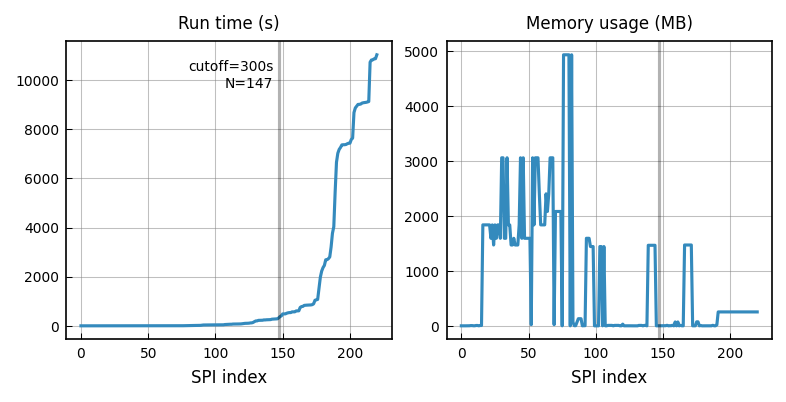

In [22]:
indices = np.argsort(run_time)

f, axs = plt.subplots(1, 2, figsize=(1.5 * PLOTW, 0.75 * PLOTW), layout="constrained")

plt.sca(axs[0])
plt.plot(run_time[indices])
plt.axvline(include_spi_count, color="k", alpha=0.3, label=f"cutoff={run_time_cutoff}s")
ymin, ymax = plt.ylim()
plt.text(
    include_spi_count - 4,
    0.98 * (ymin + ymax),
    (f"cutoff={run_time_cutoff}s\nN={include_spi_count}"),
    ha="right",
    va="top",
    fontsize="small",
)
# plt.legend()
plt.xlabel("SPI index")
plt.title("Run time (s)")

plt.sca(axs[1])
plt.plot(mem[indices])
plt.axvline(include_spi_count, color="k", alpha=0.3)
plt.xlabel("SPI index")
plt.title("Memory usage (MB)")

plt.savefig(analyze_test_profile_dir / f"pyspi_run_time_memory.{FORMAT}")

Estimate total run time for all SPIs and one run.

In [23]:
def estimate_total_run_time(n_samples: int, n_features: int):
    total_run_time = run_time[run_time <= run_time_cutoff].sum()

    # assume linear scaling in samples and quadratic in features
    # Nb, not strictly accurate, since some SPIs scale quadratically with sample length...
    total_run_time *= n_samples / base_n_samples
    total_run_time *= (n_features / base_n_features) ** 2
    return total_run_time

In [24]:
target_n_samples = 400
target_n_features = 200
total_run_time = estimate_total_run_time(target_n_samples, target_n_features)

print(
    f"Total run time (N={target_n_samples}, D={target_n_features}): "
    f"{total_run_time // 60:.0f} min"
)

Total run time (N=400, D=200): 118 min


Save list of selected SPIs

In [25]:
include_spis_set = set(run_time_df.loc[run_time <= run_time_cutoff].index.values)

# Keep original order
include_spis = [spi for spi in all_spis if spi in include_spis_set]

with (
    spi_list_dir / f"spi_list_select_{run_time_cutoff}s_{include_spi_count}.txt"
).open("w") as file:
    print("\n".join(include_spis), file=file)

Mark SPIs excluded by run time.

In [26]:
for spi in run_time_df.loc[run_time > run_time_cutoff].index.values:
    spi_include_codes[spi] = IncludeCode.TIME

Final include/exclude counts

In [27]:
pd.Series(spi_include_codes).value_counts()

I    147
T     92
D     37
E      8
Name: count, dtype: int64

Make a formatted table of all included SPIs, grouped by category and family identifier, including counts.

In [28]:
include_spi_table = spi_table.copy()
include_spi_table["include"] = include_spi_table["spi"].isin(include_spis_set)

include_spi_table = include_spi_table.rename(columns={"fcn": "function"})

In [29]:
include_spi_table.head(4)

,spi_id,spi,category,identifier,function,params,include
0,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},True
1,1,cov_EllipticEnvelope,basic,cov,Covariance,{'estimator': 'EllipticEnvelope'},True
2,2,cov_GraphicalLasso,basic,cov,Covariance,{'estimator': 'GraphicalLasso'},False
3,3,cov_GraphicalLassoCV,basic,cov,Covariance,{'estimator': 'GraphicalLassoCV'},True


In [30]:
include_category_spi_counts = (
    include_spi_table.groupby("category")
    .agg({"spi": "count", "include": "sum"})
    .rename(columns={"spi": "total"})
)

include_category_spi_counts

,total,include
category,,
basic,42,12
causal,13,1
distance,42,15
infotheory,43,19
misc,24,22
spectral,114,72
wavelet,6,6


In [31]:
include_category_id_counts_total = (
    include_spi_table.groupby("category")
    .agg({"identifier": "nunique"})
    .rename(columns={"identifier": "total"})
)

include_category_id_counts_include = (
    include_spi_table.query("include")
    .groupby("category")
    .agg({"identifier": "nunique"})
    .rename(columns={"identifier": "include"})
)

include_category_id_counts = pd.concat(
    [include_category_id_counts_total, include_category_id_counts_include],
    axis=1,
)

include_category_id_counts

,total,include
category,,
basic,10,4
causal,5,1
distance,13,6
infotheory,11,6
misc,4,3
spectral,17,12
wavelet,1,1


In [32]:
include_category_id_spis_counts = (
    include_spi_table.groupby(["category", "identifier"], sort=False)
    .agg({"spi_id": "count", "include": "sum", "spi": list})
    .rename(columns={"spi_id": "total"})
)

include_category_id_spis_counts.head(4)

total  include  \
category identifier                   
basic    cov             8        7   
         cov-sq          8        0   
         prec            8        0   
         prec-sq         8        0   

                                                                   spi  
category identifier                                                     
basic    cov         [cov_EmpiricalCovariance, cov_EllipticEnvelope...  
         cov-sq      [cov-sq_EmpiricalCovariance, cov-sq_EllipticEn...  
         prec        [prec_EmpiricalCovariance, prec_EllipticEnvelo...  
         prec-sq     [prec-sq_EmpiricalCovariance, prec-sq_Elliptic...

In [33]:
spi_indentifier_func_map = {
    identifier: func
    for identifier, func in zip(
        include_spi_table["identifier"], include_spi_table["function"]
    )
}

In [34]:
# Each spi on a new line, included shown in bold, excluded with exclusion code
def format_spis(spis: list[str]):
    spis_fmt = []
    for spi in spis:
        spi_fmt = f"({spi_id_map[spi] + 1:03d}) {spi}"
        if spi in include_spis_set:
            spi_fmt = f"<b>{spi_fmt}</b>"
        else:
            spi_fmt = f"{spi_fmt} ({spi_include_codes[spi].value})"
        spis_fmt.append(spi_fmt)
    return "<br>".join(spis_fmt)


# Add counts and short identifier names
def format_index(idx: tuple[str, str]):
    category, identifier = idx
    func = spi_indentifier_func_map[identifier]

    cat_spi_total, cat_spi_include = include_category_spi_counts.loc[
        category, ["total", "include"]
    ]
    cat_id_total, cat_id_include = include_category_id_counts.loc[
        category, ["total", "include"]
    ]
    id_spi_total, id_spi_include = include_category_id_spis_counts.loc[
        (category, identifier), ["total", "include"]
    ]

    category_fmt = (
        f"{category}<br>"
        f"({cat_id_include}/{cat_id_total} families)<br>"
        f"({cat_spi_include}/{cat_spi_total} SPIs)"
    )

    identifier_fmt = f"{identifier} ({func})<br>({id_spi_include}/{id_spi_total} SPIs)"
    return category_fmt, identifier_fmt


include_spi_table_fmt = include_category_id_spis_counts.copy()
include_spi_table_fmt = include_spi_table_fmt.drop(columns=["total", "include"])
include_spi_table_fmt["spi"] = include_spi_table_fmt["spi"].map(format_spis)
include_spi_table_fmt.index = include_spi_table_fmt.index.map(format_index)
include_spi_table_fmt.index.names = ["Category", "Family"]
include_spi_table_fmt.columns = ["SPIs"]

In [35]:
include_spi_table_fmt_style = include_spi_table_fmt.style.set_properties(
    **{"text-align": "left"}
).set_table_styles(
    [
        {"selector": "th", "props": [("text-align", "center")]},
        {
            "selector": ".row_heading",
            "props": [("text-align", "center"), ("vertical-align", "top")],
        },
    ]
)

include_spi_table_fmt_style

In [36]:
include_spi_table_fmt_style.to_html(analyze_test_profile_dir / "include_spi_table.html")

### Visualize example matrices for selected SPIs

In [37]:
def matshow(
    mat: np.ndarray,
    vmin: float | None = None,
    vmax: float | None = None,
    **kwargs,
):
    if vmax is None:
        vmax = np.max(np.abs(mat))
    if vmin is None:
        vmin = -vmax

    kwargs = {
        "cmap": FC_CMAP,
        "interpolation": "none",
        **kwargs,
    }
    plt.imshow(mat, vmin=vmin, vmax=vmax, **kwargs)
    plt.xticks([])
    plt.yticks([])

In [38]:
mat_df = (
    df.loc[df["spi"].isin(include_spis_set)]
    .query(f"n_samples == {base_n_samples} and n_features == {base_n_features}")
    .reset_index(drop=True)
)

print(mat_df.shape)
mat_df.iloc[:4, :10]

(147, 13)


,spi_id,spi,category,identifier,fcn,params,n_samples,n_features,success,run_time
0,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},400,200,True,0.149938
1,1,cov_EllipticEnvelope,basic,cov,Covariance,{'estimator': 'EllipticEnvelope'},400,200,True,2.553292
2,3,cov_GraphicalLassoCV,basic,cov,Covariance,{'estimator': 'GraphicalLassoCV'},400,200,True,86.003288
3,4,cov_LedoitWolf,basic,cov,Covariance,{'estimator': 'LedoitWolf'},400,200,True,0.025151


In [39]:
# mapping of (category, identifier) -> row indices
row_lut = defaultdict(list)

for idx, row in mat_df.iterrows():
    row_lut[(row["category"], row["identifier"])].append(idx)

In [40]:
nrow = len(row_lut)
ncol = max(len(v) for v in row_lut.values())
print(nrow, ncol)

33 12


SPIs organized with each identifier family on another row.

In [41]:
def plot_example_matrices_by_family(category: str | None = None):
    if category is not None:
        cat_row_lut = {
            (cat, id): indices
            for (cat, id), indices in row_lut.items()
            if cat == category.lower()
        }
    else:
        cat_row_lut = row_lut

    plotw = 1.5
    ploth = 0.85 * plotw

    # wrap functions with lots of SPIs to max 7 cols
    ncol = 7
    wrap_cat_row_lut = {}
    for (cat, id), indices in cat_row_lut.items():
        for row_ind in range(int(np.ceil(len(indices) / ncol))):
            wrap_cat_row_lut[(cat, id, row_ind)] = indices[
                row_ind * ncol : (row_ind + 1) * ncol
            ]

    nrow = len(wrap_cat_row_lut)

    f, axs = plt.subplots(
        nrow,
        ncol,
        figsize=(ncol * plotw, nrow * ploth),
        layout="constrained",
        squeeze=False,
    )

    for ii, (cat, id, row_ind) in enumerate(wrap_cat_row_lut):
        if ii >= nrow:
            break

        indices = wrap_cat_row_lut[(cat, id, row_ind)]
        for jj in range(ncol):
            plt.sca(axs[ii, jj])
            if jj >= len(indices):
                plt.axis("off")
                continue

            idx = indices[jj]
            spi = mat_df.loc[idx, "spi"]
            mat = mat_df.loc[idx, "mat"]
            mat = mat.reshape(base_n_features, base_n_features)

            vmax = max(np.nanquantile(np.abs(mat), 0.95), 1e-8)
            matshow(mat, vmax=vmax)
            cbar = plt.colorbar(fraction=0.05, pad=0.05)
            cbar.ax.tick_params(labelsize="xx-small")

            title = f"({spi_id_map[spi] + 1:03d}) {spi}"
            plt.title(title[:26], fontsize="x-small", pad=4)
            if jj == 0:
                ylabel = f"{cat} - {id}"
                if row_ind > 0:
                    ylabel = f"{ylabel} (cont)"
                plt.ylabel(ylabel, fontsize="small")

    return f

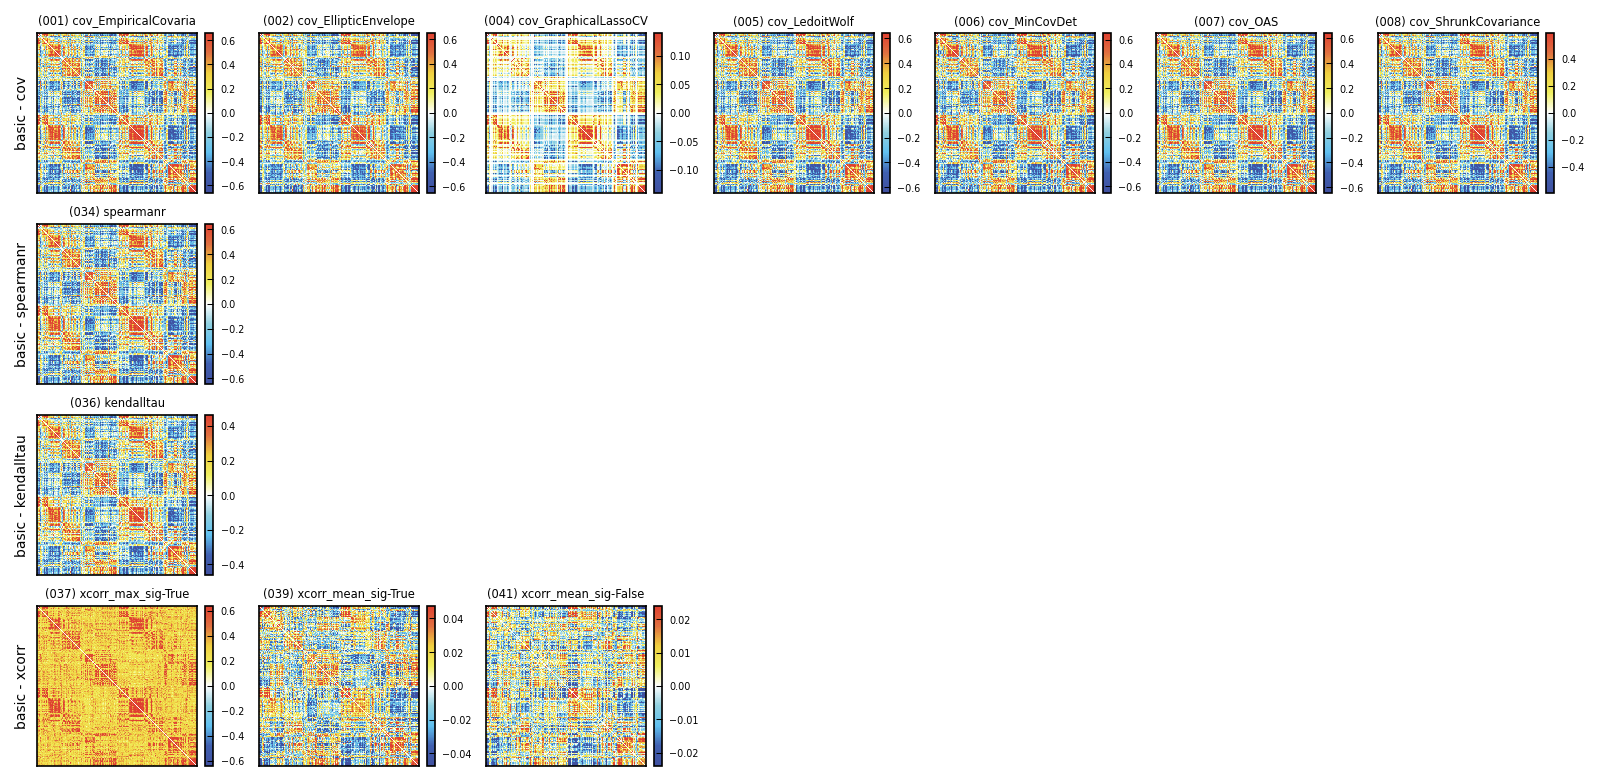

In [42]:
f = plot_example_matrices_by_family("basic")
f.show()

In [43]:
f = plot_example_matrices_by_family()
f.savefig(
    analyze_test_profile_dir / "example_spi_matrices_by_family.png",
    bbox_inches="tight",
)
plt.close(f)

In [44]:
def plot_example_matrices_flat(category: str | None = None):
    if category is not None:
        cat_mat_df = mat_df.query(f"category == '{category}'")
    else:
        cat_mat_df = mat_df

    plotw = 1.5
    ploth = 0.85 * plotw

    ncol = 10
    nrow = int(np.ceil(len(cat_mat_df) / ncol))

    f, axs = plt.subplots(
        nrow, ncol, figsize=(ncol * plotw, nrow * ploth), layout="constrained"
    )
    axs = axs.flatten()

    for ii, ax in enumerate(axs):
        plt.sca(ax)
        if ii >= len(cat_mat_df):
            plt.axis("off")
            continue

        cat = mat_df.loc[ii, "category"]
        spi = mat_df.loc[ii, "spi"]

        mat = mat_df.loc[ii, "mat"]
        mat = mat.reshape(base_n_features, base_n_features)

        vmax = max(np.nanquantile(np.abs(mat), 0.95), 1e-8)
        matshow(mat, vmax=vmax)
        cbar = plt.colorbar(fraction=0.05, pad=0.05)
        cbar.ax.tick_params(labelsize="xx-small")

        title = f"({cat[0].upper()}) ({spi_id_map[spi] + 1:03d}) {spi}"
        plt.title(title[:26], fontsize="x-small", pad=4)

    return f

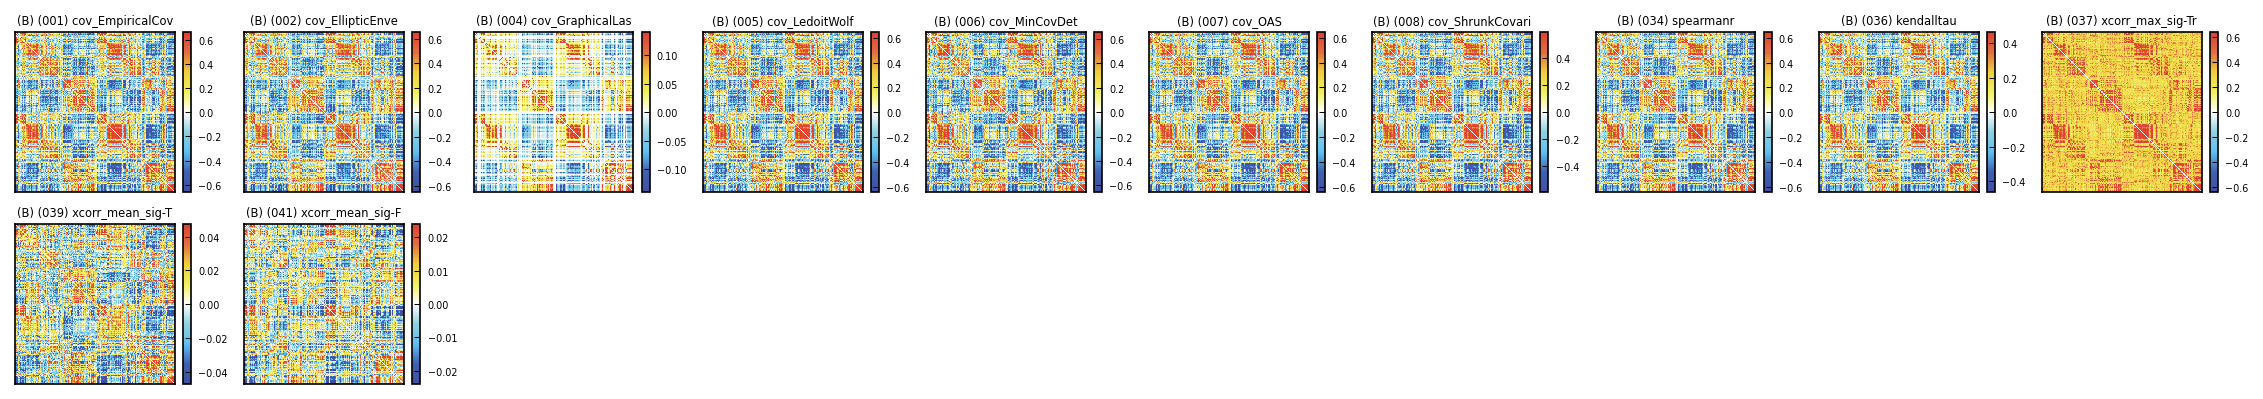

In [45]:
f = plot_example_matrices_flat("basic")
f.show()

In [46]:
f = plot_example_matrices_flat()
f.savefig(
    analyze_test_profile_dir / "example_spi_matrices_flat.png",
    bbox_inches="tight",
)
plt.close(f)